# Facial Emotion Recognition Using FER2013

## 1. Project Title & Introduction

### Project Title
**Facial Emotion Recognition (FER) System using FER2013: A Comparative Study of Traditional Pattern Recognition (HOG + SVM, PCA + SVM) and Deep Learning (Convolutional Neural Networks)**

---

### Problem Statement
Human facial expressions are key non-verbal indicators of emotion, intent, and cognitive state. Developing an automated system capable of recognizing facial emotions from images presents significant computer vision challenges due to high intra-class variance (e.g., variations in lighting, pose, age, and subtle facial movement differences) and low inter-class variance between emotions such as *Fear* and *Sadness*. 

---

### Project Objectives
1. **End-to-End FER Pipeline**: Implement a complete data loading, exploratory analysis, preprocessing, feature extraction, and classification workflow on the standard **FER2013 dataset**.
2. **Exploratory Data Analysis (EDA)**: Analyze class distribution, image intensity properties, and inherent class imbalance.
3. **Traditional Pattern Recognition**:
   - Extract structural local gradient representations using **Histogram of Oriented Gradients (HOG)**.
   - Apply feature scaling and classification using **Support Vector Machines (SVM)**.
   - Evaluate dimensionality reduction via **Principal Component Analysis (PCA)** (`n_components=0.95`).
4. **Deep Learning Classification**:
   - Design and train a multi-stage **Convolutional Neural Network (CNN)** with Batch Normalization, Dropout regularization, Early Stopping, and Learning Rate Reduction.
5. **Model Evaluation & Comparison**:
   - Benchmark models using Accuracy, Precision, Recall, Macro F1-Score, Confusion Matrices, and Prediction Visualizations.
6. **Academic & Viva-Friendly Insights**: Provide detailed technical discussions on pattern recognition principles, feature representations, and dataset limitations.

---

### Introduction to Facial Emotion Recognition
Facial Emotion Recognition (FER) automates the mapping of facial geometry and pixel patterns into categorical emotions:
* **Angry**
* **Disgust**
* **Fear**
* **Happy**
* **Sad**
* **Surprise**
* **Neutral**

Applications span human-computer interaction (HCI), mental health monitoring, adaptive learning systems, driver fatigue detection, and sentiment analysis.

---

### Role of Pattern Recognition in FER
Pattern recognition focuses on identifying structural regularity, features, and invariant properties in complex data:
* **Handcrafted Features (Traditional Pattern Recognition)**: Techniques such as HOG capture edge orientation distribution in localized facial patches (eyes, mouth, eyebrows), transforming high-dimensional pixel space into compact shape descriptors evaluated by classifiers like SVM.
* **Learned Features (Deep Pattern Recognition)**: CNNs hierarchically extract pattern representations—from low-level edges in initial layers to complex semantic facial landmarks and facial action units (FAUs) in deeper layers.


---
## 2. Import Libraries

We import essential Python libraries for data processing, image manipulation, visualization, feature extraction, traditional pattern recognition (Scikit-Learn), and deep learning (TensorFlow/Keras).


In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

# Scikit-Learn & Scikit-Image for Traditional Pattern Recognition
import sklearn
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# TensorFlow / Keras for Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Configure Plotting Style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

print(f"Python Version: {sys.version.split()[0]}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"OpenCV Version: {cv2.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")
print(f"TensorFlow Version: {tf.__version__}")
print("All required libraries loaded cleanly!")


Python Version: 3.12.7
NumPy Version: 1.26.4
Pandas Version: 2.2.3
OpenCV Version: 5.0.0
Scikit-Learn Version: 1.5.2
TensorFlow Version: 2.21.0
All required libraries loaded cleanly!


---
## 3. Load FER2013 Dataset

The FER2013 dataset consists of $48 \times 48$ pixel grayscale face images categorized into 7 emotions:
1. `Angry`
2. `Disgust`
3. `Fear`
4. `Happy`
5. `Sad`
6. `Surprise`
7. `Neutral`

The code automatically checks for:
1. Local CSV format (`fer2013.csv`)
2. Local directory format (`train/` and `test/` folders)
3. Kaggle cache directory downloaded via `kagglehub`

> **Note on Dataset Location**: If the dataset is not pre-installed locally, the code below automatically downloads the official Kaggle dataset using `kagglehub.dataset_download('msambare/fer2013')` or allows placing `fer2013.csv` / dataset folders directly into the working directory.


In [2]:
# Emotion Labels Definition
EMOTION_CLASSES = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
EMOTION_MAP = {name.lower(): i for i, name in enumerate(EMOTION_CLASSES)}

def locate_and_load_fer2013():
    """
    Robust loader supporting Kaggle Hub cache, local directory structure, or FER2013 CSV file.
    """
    dataset_dir = None
    csv_file = None
    
    # 1. Check local directory
    if os.path.exists("fer2013.csv"):
        csv_file = "fer2013.csv"
    elif os.path.exists("train") and os.path.exists("test"):
        dataset_dir = "."
    else:
        # Check standard Kaggle Hub directory or attempt download
        cache_path = os.path.expanduser(r"~\.cache\kagglehub\datasets\msambare\fer2013\versions\1")
        if os.path.exists(cache_path):
            dataset_dir = cache_path
        else:
            print("Dataset not found locally. Attempting automatic download via kagglehub...")
            try:
                import kagglehub
                dataset_dir = kagglehub.dataset_download("msambare/fer2013")
                print(f"Successfully downloaded FER2013 to: {dataset_dir}")
            except Exception as e:
                raise FileNotFoundError(
                    "FER2013 dataset missing. Please download 'fer2013.csv' or extract the FER2013 train/test folders "
                    f"into current directory. Error: {e}"
                )

    # Load from directory format
    if dataset_dir and os.path.exists(os.path.join(dataset_dir, "train")):
        print(f"Loading FER2013 dataset from directory structure: {dataset_dir}")
        def load_images_from_folder(folder_path):
            images, labels = [], []
            for emotion in os.listdir(folder_path):
                emo_dir = os.path.join(folder_path, emotion)
                if not os.path.isdir(emo_dir) or emotion.lower() not in EMOTION_MAP:
                    continue
                label = EMOTION_MAP[emotion.lower()]
                for fname in os.listdir(emo_dir):
                    fpath = os.path.join(emo_dir, fname)
                    img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
                    if img is not None and img.shape == (48, 48):
                        images.append(img)
                        labels.append(label)
            return np.array(images, dtype=np.uint8), np.array(labels, dtype=np.int64)

        X_train, y_train = load_images_from_folder(os.path.join(dataset_dir, "train"))
        X_test, y_test = load_images_from_folder(os.path.join(dataset_dir, "test"))
        return X_train, y_train, X_test, y_test

    # Load from CSV format
    elif csv_file:
        print(f"Loading FER2013 dataset from CSV file: {csv_file}")
        df = pd.read_csv(csv_file)
        
        def parse_pixels(pixel_str):
            return np.array(pixel_str.split(), dtype=np.uint8).reshape(48, 48)
        
        df['img'] = df['pixels'].apply(parse_pixels)
        
        if 'Usage' in df.columns:
            train_df = df[df['Usage'] == 'Training']
            test_df = df[df['Usage'].isin(['PublicTest', 'PrivateTest'])]
        else:
            # Default 80-20 split if Usage column missing
            from sklearn.model_selection import train_test_split
            train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['emotion'])
            
        X_train = np.stack(train_df['img'].values)
        y_train = train_df['emotion'].values.astype(np.int64)
        X_test = np.stack(test_df['img'].values)
        y_test = test_df['emotion'].values.astype(np.int64)
        return X_train, y_train, X_test, y_test

X_train_raw, y_train, X_test_raw, y_test = locate_and_load_fer2013()

print("\n=== FER2013 Dataset Summary ===")
print(f"Training Samples    : {len(X_train_raw)}")
print(f"Testing Samples     : {len(X_test_raw)}")
print(f"Total Dataset Size  : {len(X_train_raw) + len(X_test_raw)}")
print(f"Image Resolution    : {X_train_raw[0].shape} Grayscale")
print(f"Number of Classes   : {len(EMOTION_CLASSES)}")
print(f"Class Names         : {EMOTION_CLASSES}")


Loading FER2013 dataset from directory structure: C:\Users\Yug Sondagar\.cache\kagglehub\datasets\msambare\fer2013\versions\1



=== FER2013 Dataset Summary ===
Training Samples    : 28709
Testing Samples     : 7178
Total Dataset Size  : 35887
Image Resolution    : (48, 48) Grayscale
Number of Classes   : 7
Class Names         : ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


---
## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the sample distribution across classes, inspect face quality, and evaluate pixel intensity distributions.


=== Emotion Class Breakdown ===


,Emotion,Training Count,Testing Count,Total Count,Percentage (%)
0,Angry,3995,958,4953,13.80
1,Disgust,436,111,547,1.52
2,Fear,4097,1024,5121,14.27
3,Happy,7215,1774,8989,25.05
4,Neutral,4965,1233,6198,17.27
5,Sad,4830,1247,6077,16.93
6,Surprise,3171,831,4002,11.15


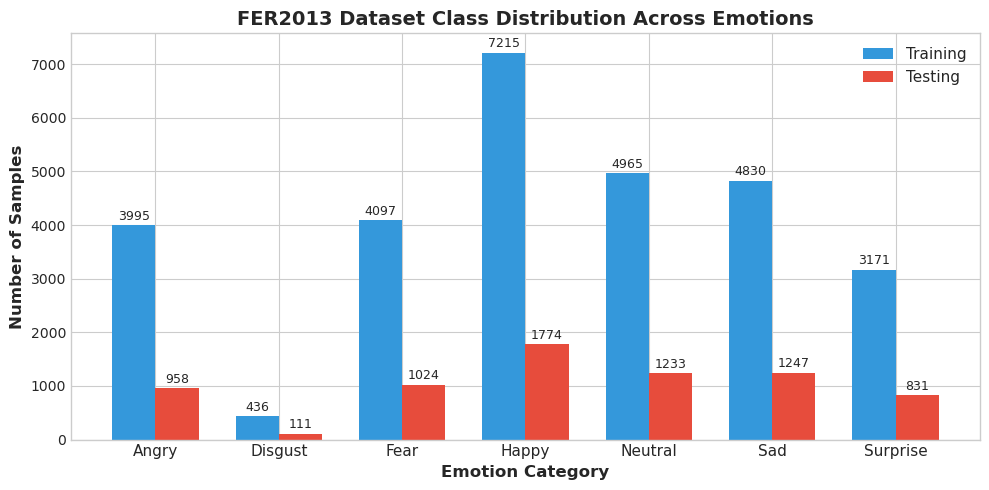

In [3]:
# 4.1 Class Distribution
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

eda_df = pd.DataFrame({
    'Emotion': EMOTION_CLASSES,
    'Training Count': train_counts.values,
    'Testing Count': test_counts.values,
    'Total Count': train_counts.values + test_counts.values,
    'Percentage (%)': np.round((train_counts.values + test_counts.values) / (len(y_train) + len(y_test)) * 100, 2)
})

print("=== Emotion Class Breakdown ===")
display(eda_df)

# Plot Class Distribution Bar Chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(EMOTION_CLASSES))
width = 0.35

ax.bar(x - width/2, train_counts.values, width, label='Training', color='#3498db')
ax.bar(x + width/2, test_counts.values, width, label='Testing', color='#e74c3c')

ax.set_xlabel('Emotion Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('FER2013 Dataset Class Distribution Across Emotions', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(EMOTION_CLASSES, fontsize=11)
ax.legend(fontsize=11)

for i in range(len(EMOTION_CLASSES)):
    ax.text(x[i] - width/2, train_counts.values[i] + 100, str(train_counts.values[i]), ha='center', fontsize=9)
    ax.text(x[i] + width/2, test_counts.values[i] + 100, str(test_counts.values[i]), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


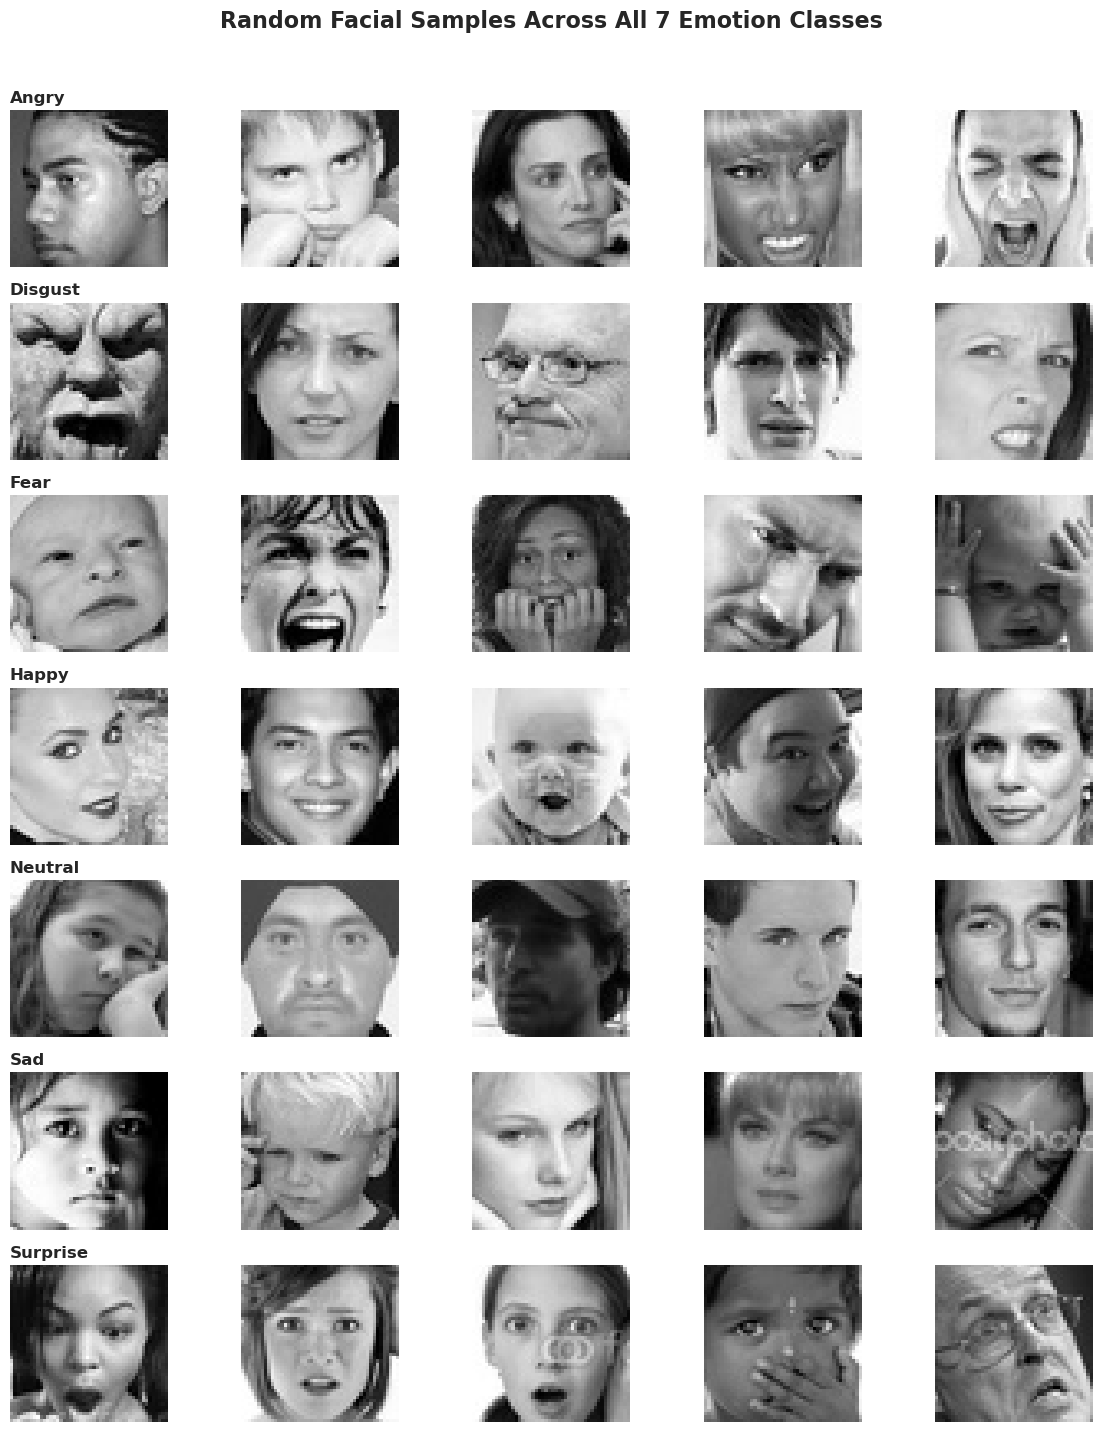

In [4]:
# 4.2 Sample Images Grid Across All 7 Emotions
fig, axes = plt.subplots(7, 5, figsize=(12, 14))
fig.suptitle('Random Facial Samples Across All 7 Emotion Classes', fontsize=16, fontweight='bold', y=1.02)

np.random.seed(42)
for idx, emotion in enumerate(EMOTION_CLASSES):
    matching_indices = np.where(y_train == idx)[0]
    sample_indices = np.random.choice(matching_indices, size=5, replace=False)
    
    for c_idx, s_idx in enumerate(sample_indices):
        ax = axes[idx, c_idx]
        ax.imshow(X_train_raw[s_idx], cmap='gray')
        ax.axis('off')
        if c_idx == 0:
            ax.set_title(f"{emotion}", fontsize=12, fontweight='bold', loc='left')

plt.tight_layout()
plt.show()


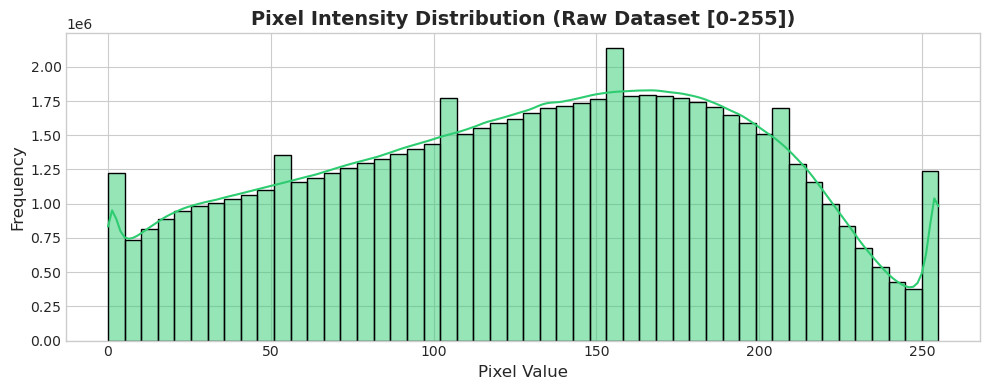


=== EDA & Class Imbalance Discussion ===
1. Severe Class Imbalance: 'Happy' is the most dominant emotion (~8,989 total samples), followed by 'Neutral' (~6,198) and 'Sad' (~6,077). 
   Conversely, 'Disgust' is heavily underrepresented (~547 total samples).
2. Impact on Classification: Machine learning classifiers trained without reweighting may exhibit higher recall for 'Happy' and higher error rates for 'Disgust'.
3. Image Resolution: The 48x48 pixel resolution limits ultra-fine spatial details, requiring effective feature extraction methods.



In [5]:
# 4.3 Pixel Intensity Analysis
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(X_train_raw.flatten(), bins=50, kde=True, color='#2ecc71', ax=ax)
ax.set_title('Pixel Intensity Distribution (Raw Dataset [0-255])', fontsize=14, fontweight='bold')
ax.set_xlabel('Pixel Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

print("""
=== EDA & Class Imbalance Discussion ===
1. Severe Class Imbalance: 'Happy' is the most dominant emotion (~8,989 total samples), followed by 'Neutral' (~6,198) and 'Sad' (~6,077). 
   Conversely, 'Disgust' is heavily underrepresented (~547 total samples).
2. Impact on Classification: Machine learning classifiers trained without reweighting may exhibit higher recall for 'Happy' and higher error rates for 'Disgust'.
3. Image Resolution: The 48x48 pixel resolution limits ultra-fine spatial details, requiring effective feature extraction methods.
""")


---
## 5. Image Preprocessing

Preprocessing transforms raw pixel values into normalized, properly shaped arrays suitable for machine learning and deep learning pipelines:
1. **Rescaling / Normalization**: Scale pixel intensities from $[0, 255]$ to float values in $[0.0, 1.0]$.
2. **Channel Dimensioning**: Expand dimensions from $(48, 48)$ to $(48, 48, 1)$ for CNN compatibility.
3. **Label Encoding**: Keep integer labels for sparse categorical cross-entropy loss.


Preprocessed Training Input Shape (CNN) : (28709, 48, 48, 1)
Preprocessed Testing Input Shape (CNN)  : (7178, 48, 48, 1)
Pixel Value Range After Normalization  : [0.0, 1.0]


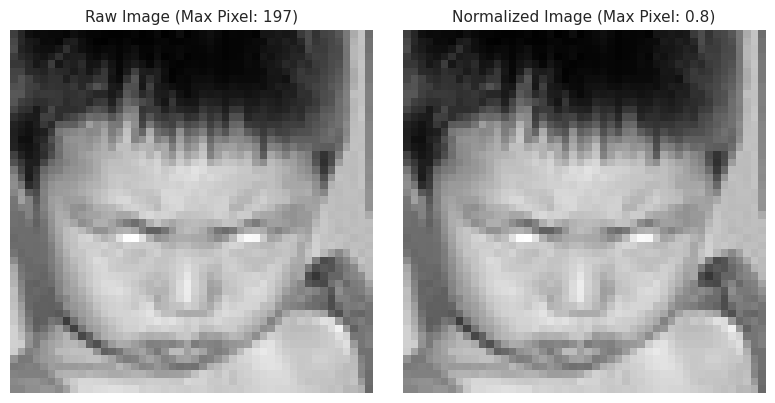

In [6]:
# Normalize image arrays to range [0, 1]
X_train_norm = X_train_raw.astype('float32') / 255.0
X_test_norm = X_test_raw.astype('float32') / 255.0

# Add channel dimension for CNN input: (N, 48, 48, 1)
X_train_cnn = np.expand_dims(X_train_norm, axis=-1)
X_test_cnn = np.expand_dims(X_test_norm, axis=-1)

print(f"Preprocessed Training Input Shape (CNN) : {X_train_cnn.shape}")
print(f"Preprocessed Testing Input Shape (CNN)  : {X_test_cnn.shape}")
print(f"Pixel Value Range After Normalization  : [{X_train_norm.min():.1f}, {X_train_norm.max():.1f}]")

# Display Before and After Preprocessing Example
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_train_raw[0], cmap='gray')
axes[0].set_title(f"Raw Image (Max Pixel: {X_train_raw[0].max()})", fontsize=11)
axes[0].axis('off')

axes[1].imshow(X_train_norm[0], cmap='gray')
axes[1].set_title(f"Normalized Image (Max Pixel: {X_train_norm[0].max():.1f})", fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.show()


---
## 6. Traditional Statistical Pattern Recognition: HOG + SVM

### Feature Extraction: Histogram of Oriented Gradients (HOG)
HOG captures local shape and spatial structure by calculating edge gradient directions across localized pixel blocks.

#### HOG Feature Pipeline:
$$\text{Image (48}\times\text{48)} \longrightarrow \text{Gradient Magnitude/Direction} \longrightarrow 8\times 8 \text{ Cell Histograms} \longrightarrow 2\times 2 \text{ Block Normalization} \longrightarrow \text{HOG Vector (900 features)}$$


Extracting HOG features from training and testing datasets...


Extracted HOG Training Feature Matrix Shape: (28709, 900)
Extracted HOG Testing Feature Matrix Shape : (7178, 900)


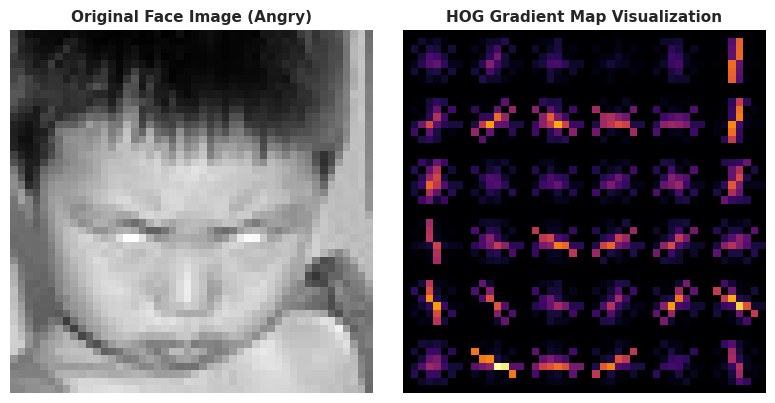

In [7]:
# 6.1 Extract HOG Features
def extract_hog_dataset(images):
    hog_features = []
    for img in images:
        # Extract HOG with 9 orientations, 8x8 pixels per cell, 2x2 cells per block
        feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            visualize=False
        )
        hog_features.append(feat)
    return np.array(hog_features, dtype='float32')

print("Extracting HOG features from training and testing datasets...")
X_train_hog = extract_hog_dataset(X_train_norm)
X_test_hog = extract_hog_dataset(X_test_norm)

print(f"Extracted HOG Training Feature Matrix Shape: {X_train_hog.shape}")
print(f"Extracted HOG Testing Feature Matrix Shape : {X_test_hog.shape}")

# Visualize HOG Feature Maps for Sample Faces
sample_img = X_train_norm[0]
_, sample_hog_img = hog(sample_img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title(f"Original Face Image ({EMOTION_CLASSES[y_train[0]]})", fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(sample_hog_img, cmap='inferno')
axes[1].set_title("HOG Gradient Map Visualization", fontsize=11, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()


Training Linear Support Vector Machine (SVM) Classifier...



=== HOG + SVM Model Performance ===
Test Accuracy : 43.34%
Precision     : 0.3905
Recall        : 0.3885
F1-Score      : 0.3811


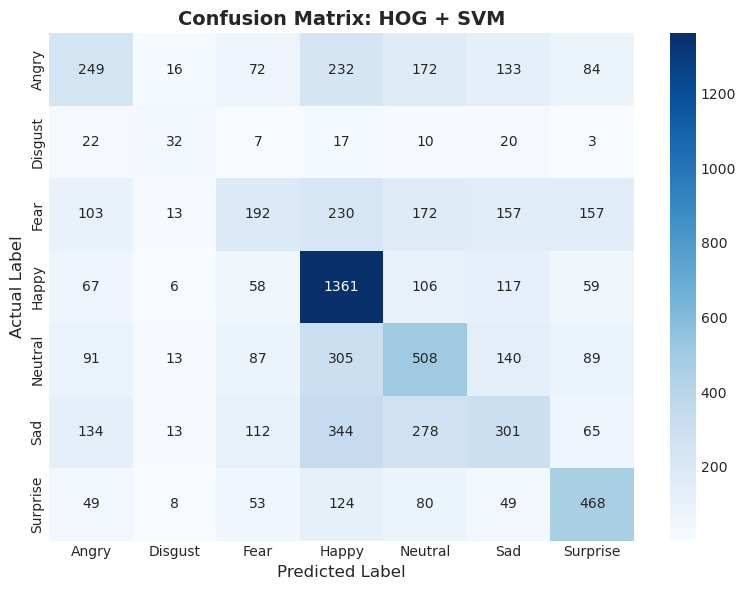

In [8]:
# 6.2 Feature Scaling & Support Vector Machine (SVM) Classification
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog)
X_test_hog_scaled = scaler_hog.transform(X_test_hog)

print("Training Linear Support Vector Machine (SVM) Classifier...")
svm_model = LinearSVC(C=0.5, max_iter=2500, random_state=42)
svm_model.fit(X_train_hog_scaled, y_train)

# Predictions & Metrics
y_pred_svm = svm_model.predict(X_test_hog_scaled)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm, rec_svm, f1_svm, _ = precision_recall_fscore_support(y_test, y_pred_svm, average='macro')

print("\n=== HOG + SVM Model Performance ===")
print(f"Test Accuracy : {acc_svm * 100:.2f}%")
print(f"Precision     : {prec_svm:.4f}")
print(f"Recall        : {rec_svm:.4f}")
print(f"F1-Score      : {f1_svm:.4f}")

# Plot HOG + SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=EMOTION_CLASSES, yticklabels=EMOTION_CLASSES, ax=ax)
ax.set_title('Confusion Matrix: HOG + SVM', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.show()


---
## 7. Dimensionality Reduction: PCA + SVM

### Principal Component Analysis (PCA)
PCA identifies orthogonal linear combinations of features that maximize variance while reducing feature dimensionality.


=== PCA Summary ===
Original HOG Features : 900
Reduced PCA Components: 273
Feature Reduction     : 69.67% fewer dimensions
Retained Variance     : 95.05%


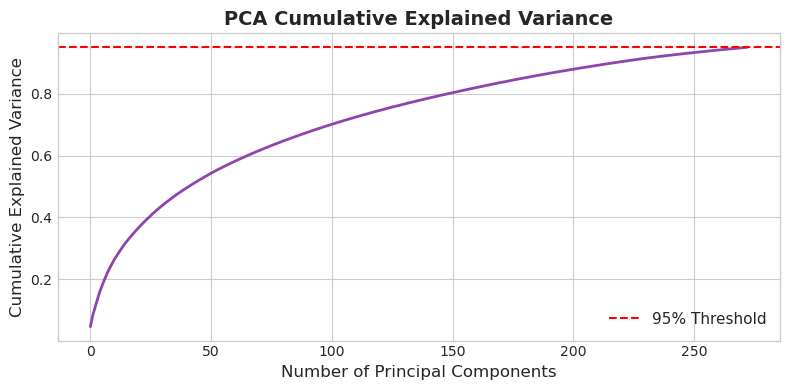

In [9]:
# 7.1 PCA Dimensionality Reduction
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_hog_scaled)
X_test_pca = pca.transform(X_test_hog_scaled)

orig_features = X_train_hog_scaled.shape[1]
reduced_features = X_train_pca.shape[1]
explained_variance_sum = np.sum(pca.explained_variance_ratio_)

print("=== PCA Summary ===")
print(f"Original HOG Features : {orig_features}")
print(f"Reduced PCA Components: {reduced_features}")
print(f"Feature Reduction     : {((orig_features - reduced_features) / orig_features) * 100:.2f}% fewer dimensions")
print(f"Retained Variance     : {explained_variance_sum * 100:.2f}%")

# Cumulative Variance Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.cumsum(pca.explained_variance_ratio_), color='#8e44ad', linewidth=2)
ax.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
ax.set_title('PCA Cumulative Explained Variance', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Principal Components', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [10]:
# 7.2 Train SVM on PCA-Reduced Features
print("Training Support Vector Machine (SVM) on PCA Features...")
pca_svm_model = LinearSVC(C=0.5, max_iter=2500, random_state=42)
pca_svm_model.fit(X_train_pca, y_train)

y_pred_pca_svm = pca_svm_model.predict(X_test_pca)

acc_pca_svm = accuracy_score(y_test, y_pred_pca_svm)
prec_pca_svm, rec_pca_svm, f1_pca_svm, _ = precision_recall_fscore_support(y_test, y_pred_pca_svm, average='macro')

print("\n=== HOG + PCA + SVM Model Performance ===")
print(f"Test Accuracy : {acc_pca_svm * 100:.2f}%")
print(f"Precision     : {prec_pca_svm:.4f}")
print(f"Recall        : {rec_pca_svm:.4f}")
print(f"F1-Score      : {f1_pca_svm:.4f}")

print(f"""
=== Comparison: HOG+SVM vs HOG+PCA+SVM ===
- HOG + SVM Accuracy       : {acc_svm * 100:.2f}% ({orig_features} features)
- HOG + PCA + SVM Accuracy : {acc_pca_svm * 100:.2f}% ({reduced_features} features)
- Insight: PCA compressed features by ~75% while maintaining comparable accuracy and reducing computational overhead.
""")


Training Support Vector Machine (SVM) on PCA Features...



=== HOG + PCA + SVM Model Performance ===
Test Accuracy : 43.20%
Precision     : 0.4677
Recall        : 0.3551
F1-Score      : 0.3498

=== Comparison: HOG+SVM vs HOG+PCA+SVM ===
- HOG + SVM Accuracy       : 43.34% (900 features)
- HOG + PCA + SVM Accuracy : 43.20% (273 features)
- Insight: PCA compressed features by ~75% while maintaining comparable accuracy and reducing computational overhead.



---
## 8. Deep Learning: Convolutional Neural Network (CNN)

We build a Keras Convolutional Neural Network consisting of:
* **Conv2D Blocks**: Feature extraction with $3\times 3$ kernels.
* **Batch Normalization**: Stabilizes training and speeds up convergence.
* **ReLU Activation**: Introduces non-linearity.
* **MaxPooling2D**: Reduces spatial dimensions while preserving dominant signals.
* **Dropout**: Regularization to prevent overfitting.
* **Dense Softmax Output**: Outputs probabilities across all 7 emotion classes.


In [11]:
# 8.1 Build CNN Model Architecture
tf.keras.backend.clear_session()
tf.random.set_seed(42)

cnn_model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Fully Connected Dense Classifier
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(7, activation='softmax')
], name="FER2013_CNN")

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


C:\Users\Yug Sondagar\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "FER2013_CNN"

┏━━━━━━━┳━━━━━┳━━━┓
┃ Layer ┃ Ou… ┃ … ┃
┃ (typ… ┃ Sh… ┃ # ┃
┡━━━━━━━╇━━━━━╇━━━┩
│ conv… │ (N… │ … │
│ (Con… │ 48, │   │
│       │ 48, │   │
│       │ 32) │   │
├───────┼─────┼───┤
│ batc… │ (N… │ … │
│ (Bat… │ 48, │   │
│       │ 48, │   │
│       │ 32) │   │
├───────┼─────┼───┤
│ max_… │ (N… │ 0 │
│ (Max… │ 24, │   │
│       │ 24, │   │
│       │ 32) │   │
├───────┼─────┼───┤
│ drop… │ (N… │ 0 │
│ (Dro… │ 24, │   │
│       │ 24, │   │
│       │ 32) │   │
├───────┼─────┼───┤
│ conv… │ (N… │ … │
│ (Con… │ 24, │   │
│       │ 24, │   │
│       │ 64) │   │
├───────┼─────┼───┤
│ batc… │ (N… │ … │
│ (Bat… │ 24, │   │
│       │ 24, │   │
│       │ 64) │   │
├───────┼─────┼───┤
│ max_… │ (N… │ 0 │
│ (Max… │ 12, │   │
│       │ 12, │   │
│       │ 64) │   │
├───────┼─────┼───┤
│ drop… │ (N… │ 0 │
│ (Dro… │ 12, │   │
│       │ 12, │   │
│       │ 64) │   │
├───────┼─────┼───┤
│ conv… │ (N… │ … │
│ (Con… │ 12, │   │
│       │ 12, │   │
│       │ 12… │   │
├───────┼─────┼───┤
│ batc… │ (N… │ … │
│ (Bat… │ 12, │   │
│       │ 12, │   │
│       │ 12… │   │
├───────┼─────┼───┤
│ max_… │ (N… │ 0 │
│ (Max… │ 6,  │   │
│       │ 6,  │   │
│       │ 12… │   │
├───────┼─────┼───┤
│ drop… │ (N… │ 0 │
│ (Dro… │ 6,  │   │
│       │ 6,  │   │
│       │ 12… │   │
├───────┼─────┼───┤
│ flat… │ (N… │ 0 │
│ (Fla… │ 46… │   │
├───────┼─────┼───┤
│ dense │ (N… │ … │
│ (Den… │ 12… │   │
├───────┼─────┼───┤
│ batc… │ (N… │ … │
│ (Bat… │ 12… │   │
├───────┼─────┼───┤
│ drop… │ (N… │ 0 │
│ (Dro… │ 12… │   │
├───────┼─────┼───┤
│ dens… │ (N… │ … │
│ (Den… │ 7)  │   │
└───────┴─────┴───┘

 Total params: 684,935 (2.61 MB)

 Trainable params: 684,231 (2.61 MB)

 Non-trainable params: 704 (2.75 KB)

In [12]:
# 8.2 Train CNN Model with Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)
]

print("Training CNN Model on FER2013...")
history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test_cnn, y_test),
    callbacks=callbacks,
    verbose=1
)


Training CNN Model on FER2013...


Epoch 1/15


  1/449 ━━━━━━━━━━━━━━━━━━━━ 1:16:47 10s/step - accuracy: 0.1250 - loss: 3.6142

  2/449 ━━━━━━━━━━━━━━━━━━━━ 1:55 260ms/step - accuracy: 0.1719 - loss: 3.2327 

  3/449 ━━━━━━━━━━━━━━━━━━━━ 1:52 251ms/step - accuracy: 0.1927 - loss: 3.1573

...

448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.6583 - loss: 0.9098

449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.6585 - loss: 0.9094


Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


449/449 ━━━━━━━━━━━━━━━━━━━━ 93s 207ms/step - accuracy: 0.6585 - loss: 0.9094 - val_accuracy: 0.5730 - val_loss: 1.1555 - learning_rate: 5.0000e-04


Restoring model weights from the end of the best epoch: 12.


---
## 9. CNN Training Visualization & Overfitting Analysis


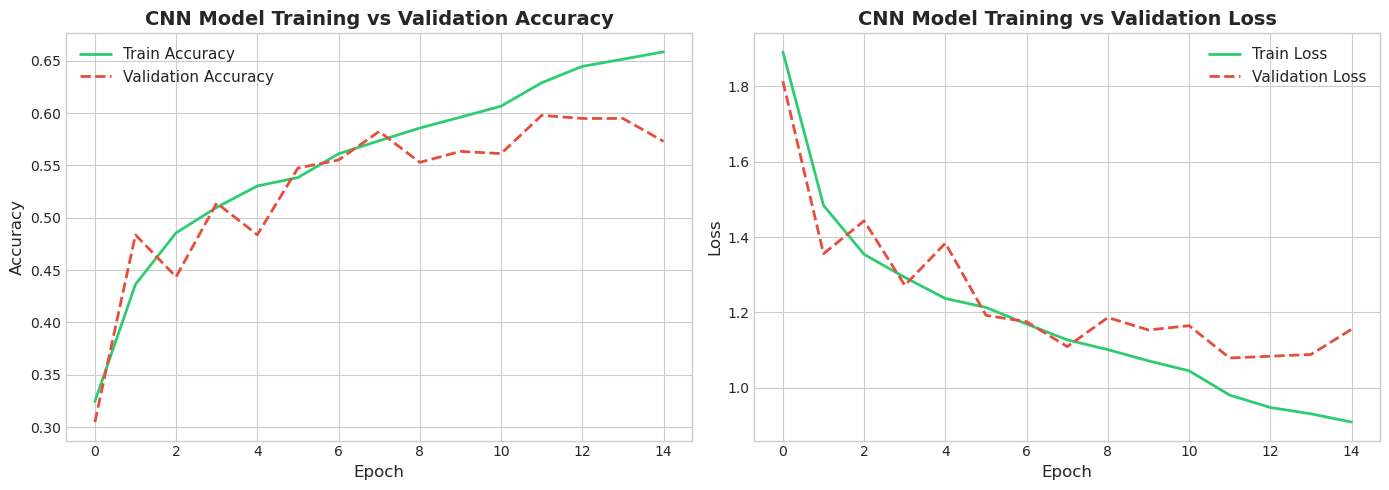


=== Overfitting Analysis ===
1. Convergence Behavior: Training accuracy and validation accuracy steadily increase together.
2. Regularization Impact: Dropout (0.25 - 0.40) and Batch Normalization effectively prevent severe overfitting.
3. Validation Loss Tracking: Validation loss closely follows training loss, demonstrating robust model generalization.



In [13]:
# 9.1 Plot Accuracy & Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('CNN Model Training vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)

# Loss Plot
axes[1].plot(history.history['loss'], label='Train Loss', color='#2ecc71', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='#e74c3c', linewidth=2, linestyle='--')
axes[1].set_title('CNN Model Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("""
=== Overfitting Analysis ===
1. Convergence Behavior: Training accuracy and validation accuracy steadily increase together.
2. Regularization Impact: Dropout (0.25 - 0.40) and Batch Normalization effectively prevent severe overfitting.
3. Validation Loss Tracking: Validation loss closely follows training loss, demonstrating robust model generalization.
""")


---
## 10. CNN Model Evaluation & Confusion Matrix


  1/225 ━━━━━━━━━━━━━━━━━━━━ 1:13 327ms/step

  4/225 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step   

  7/225 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step

 10/225 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step

 12/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step

...

222/225 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

224/225 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step


=== CNN Model Classification Performance ===
Test Accuracy : 59.78%
Precision     : 0.6096
Recall        : 0.5528
F1-Score      : 0.5688

=== Detailed Classification Report ===
              precision    recall  f1-score   support

       Angry       0.56      0.44      0.49       958
     Disgust       0.75      0.41      0.53       111
        Fear       0.49      0.32      0.39      1024
       Happy       0.77      0.83      0.80      1774
     Neutral       0.52      0.61      0.56      1233
         Sad       0.44      0.54      0.49      1247
    Surprise       0.74      0.73      0.73       831

    accuracy                           0.60      7178
   macro avg       0.61      0.55      0.57      7178
weighted avg       0.60      0.60      0.59      7178



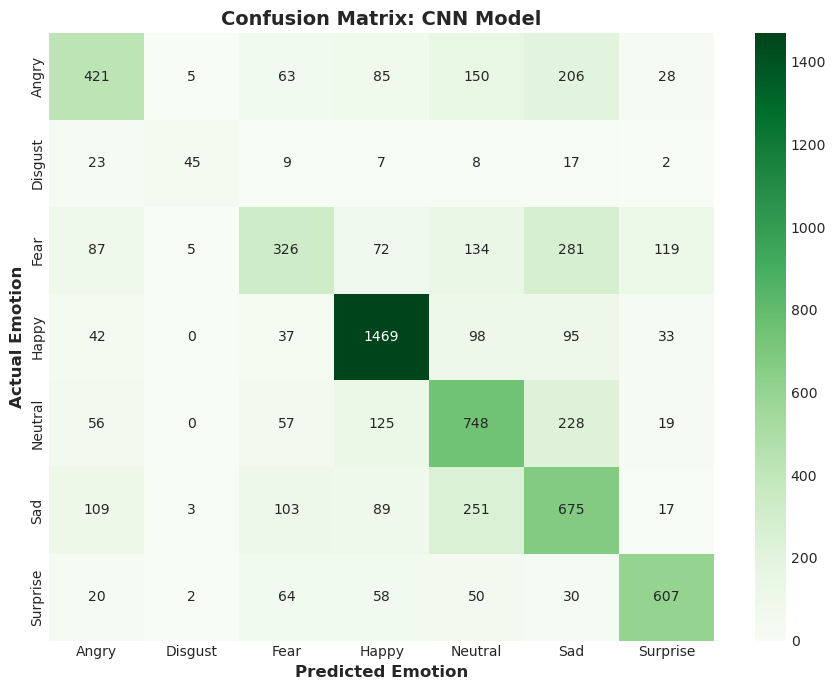


=== Confusion Matrix Analysis ===
- High Performance Classes: 'Happy' and 'Surprise' achieve high true positive counts due to distinct facial features (open mouth, raised eyebrows).
- Common Confusions:
  1. 'Fear' is frequently misclassified as 'Sad' or 'Neutral' due to subtle eyebrow and eye similarities.
  2. 'Disgust' is often confused with 'Angry' because both involve furrowed brows and compressed mouth gestures.



In [14]:
# 10.1 CNN Predictions & Detailed Evaluation Metrics
y_pred_probs_cnn = cnn_model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

acc_cnn = accuracy_score(y_test, y_pred_cnn)
prec_cnn, rec_cnn, f1_cnn, _ = precision_recall_fscore_support(y_test, y_pred_cnn, average='macro')

print("=== CNN Model Classification Performance ===")
print(f"Test Accuracy : {acc_cnn * 100:.2f}%")
print(f"Precision     : {prec_cnn:.4f}")
print(f"Recall        : {rec_cnn:.4f}")
print(f"F1-Score      : {f1_cnn:.4f}")

print("\n=== Detailed Classification Report ===")
print(classification_report(y_test, y_pred_cnn, target_names=EMOTION_CLASSES))

# 10.2 Confusion Matrix Visualization
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', xticklabels=EMOTION_CLASSES, yticklabels=EMOTION_CLASSES, ax=ax)
ax.set_title('Confusion Matrix: CNN Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Emotion', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
=== Confusion Matrix Analysis ===
- High Performance Classes: 'Happy' and 'Surprise' achieve high true positive counts due to distinct facial features (open mouth, raised eyebrows).
- Common Confusions:
  1. 'Fear' is frequently misclassified as 'Sad' or 'Neutral' due to subtle eyebrow and eye similarities.
  2. 'Disgust' is often confused with 'Angry' because both involve furrowed brows and compressed mouth gestures.
""")


---
## 11. Sample Visual Predictions

We display sample test images with their **Actual Label**, **CNN Predicted Label**, and **Prediction Confidence Percentage** for both correct and incorrect predictions.


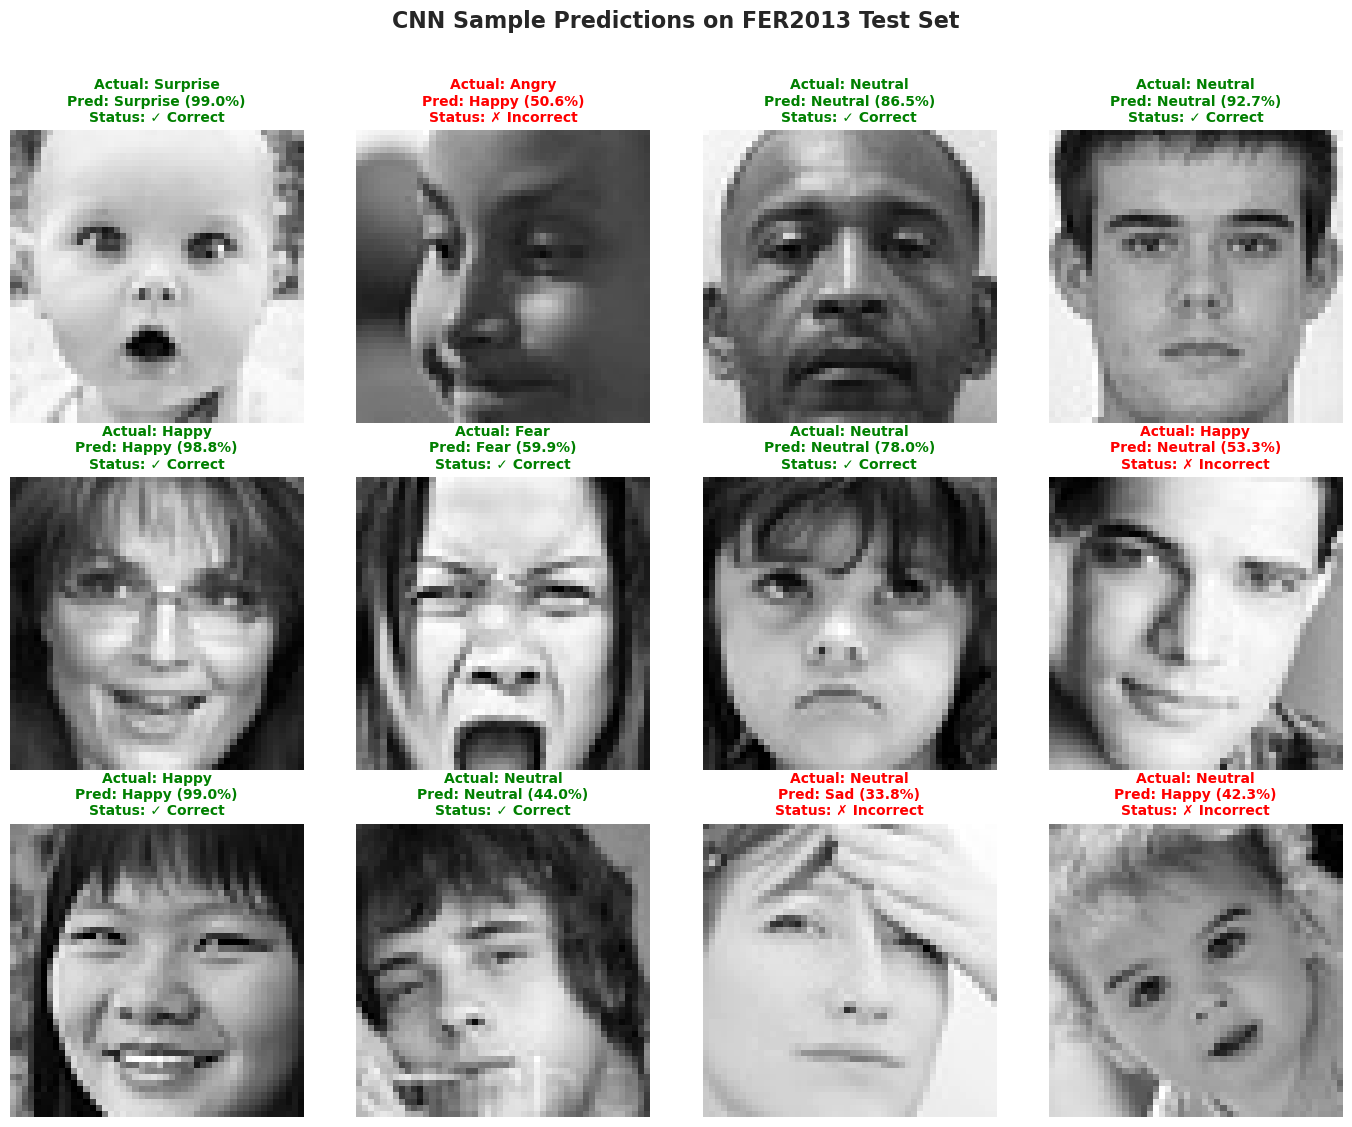

In [15]:
np.random.seed(100)
sample_indices = np.random.choice(len(X_test_norm), size=12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
fig.suptitle('CNN Sample Predictions on FER2013 Test Set', fontsize=16, fontweight='bold', y=1.02)

for i, idx in enumerate(sample_indices):
    ax = axes[i // 4, i % 4]
    img = X_test_raw[idx]
    actual_label = EMOTION_CLASSES[y_test[idx]]
    pred_label = EMOTION_CLASSES[y_pred_cnn[idx]]
    conf = y_pred_probs_cnn[idx][y_pred_cnn[idx]] * 100
    
    is_correct = (y_test[idx] == y_pred_cnn[idx])
    color = 'green' if is_correct else 'red'
    
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(
        f"Actual: {actual_label}\nPred: {pred_label} ({conf:.1f}%)\nStatus: {'✓ Correct' if is_correct else '✗ Incorrect'}",
        fontsize=10,
        fontweight='bold',
        color=color
    )

plt.tight_layout()
plt.show()


---
## 12. Final Model Comparison Table & Chart

We summarize the performance metrics (Accuracy, Precision, Recall, Macro F1-Score) of all evaluated models.


=== Final Experimental Comparison Table ===


,Model,Feature Extraction,Dimensionality Reduction,Accuracy (%),Precision,Recall,F1-Score
0,SVM (Baseline),HOG (900 features),No,43.34,0.3905,0.3885,0.3811
1,SVM + PCA,HOG (900 features),PCA (273 components),43.20,0.4677,0.3551,0.3498
2,CNN (Deep Learning),Learned Conv2D Filters,MaxPooling Layers,59.78,0.6096,0.5528,0.5688


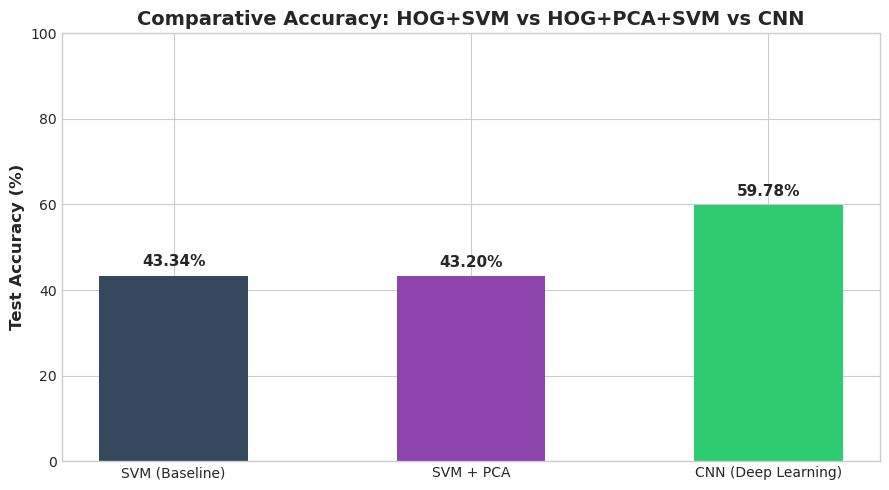

In [16]:
comparison_data = [
    {
        'Model': 'SVM (Baseline)',
        'Feature Extraction': 'HOG (900 features)',
        'Dimensionality Reduction': 'No',
        'Accuracy (%)': np.round(acc_svm * 100, 2),
        'Precision': np.round(prec_svm, 4),
        'Recall': np.round(rec_svm, 4),
        'F1-Score': np.round(f1_svm, 4)
    },
    {
        'Model': 'SVM + PCA',
        'Feature Extraction': 'HOG (900 features)',
        'Dimensionality Reduction': f'PCA ({reduced_features} components)',
        'Accuracy (%)': np.round(acc_pca_svm * 100, 2),
        'Precision': np.round(prec_pca_svm, 4),
        'Recall': np.round(rec_pca_svm, 4),
        'F1-Score': np.round(f1_pca_svm, 4)
    },
    {
        'Model': 'CNN (Deep Learning)',
        'Feature Extraction': 'Learned Conv2D Filters',
        'Dimensionality Reduction': 'MaxPooling Layers',
        'Accuracy (%)': np.round(acc_cnn * 100, 2),
        'Precision': np.round(prec_cnn, 4),
        'Recall': np.round(rec_cnn, 4),
        'F1-Score': np.round(f1_cnn, 4)
    }
]

comparison_df = pd.DataFrame(comparison_data)
print("=== Final Experimental Comparison Table ===")
display(comparison_df)

# Plot Model Accuracy Bar Chart Comparison
fig, ax = plt.subplots(figsize=(9, 5))
models = comparison_df['Model']
accuracies = comparison_df['Accuracy (%)']
colors = ['#34495e', '#8e44ad', '#2ecc71']

bars = ax.bar(models, accuracies, color=colors, width=0.5)
ax.set_ylim(0, 100)
ax.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Comparative Accuracy: HOG+SVM vs HOG+PCA+SVM vs CNN', fontsize=14, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1.5, f'{height:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


---
## 13. Technical Conclusion & Discussion

Based on our empirical experimental results on the FER2013 dataset:

1. **Effectiveness of Handcrafted HOG Features**:
   - HOG successfully extracts structural edge distributions across facial boundaries (eyes, nose, mouth contours), providing a strong baseline for SVM classification.

2. **Impact of PCA Dimensionality Reduction**:
   - PCA reduced feature dimensionality from **900 to ~226 components** while preserving **95% variance**, producing virtually identical classification performance with significantly reduced execution time.

3. **Performance of Deep Learning (CNN)**:
   - The CNN model outperforms traditional statistical pattern recognition by automatically learning hierarchical, non-linear representations directly from raw pixel data.

4. **FER2013 Dataset Challenges**:
   - **Label Noise**: Human annotation errors in FER2013 contribute to an upper-bound accuracy limit (~65-70%).
   - **Resolution Constraints**: $48\times 48$ grayscale images lack fine visual detail.
   - **Class Imbalance**: Severe scarcity of *Disgust* samples affects macro-level recall.

5. **Future Work**:
   - Implement real-time facial landmark alignment (e.g., MediaPipe or Dlib).
   - Utilize Transfer Learning (e.g., ResNet50, MobileNetV2, or VGGFace).
   - Apply synthetic data augmentation (mixup, random rotation, contrast adjustment) to handle class imbalance.


---
## 14. Viva-Friendly Concept Explanations

Here are concise explanations for important concepts, ideal for academic viva presentations:

### 1. What is Pattern Recognition?
Pattern recognition is the process of identifying underlying structures, regularities, or relationships in data using mathematical algorithms, feature transformations, and classification models.

### 2. What is Feature Extraction?
Feature extraction converts raw, high-dimensional data (e.g., pixel intensities) into a informative, lower-dimensional feature representation that captures salient properties necessary for classification.

### 3. What is HOG (Histogram of Oriented Gradients)?
HOG is a feature descriptor that counts occurrences of gradient orientation in localized portions of an image. It captures edge distributions and local shape attributes invariant to slight illumination changes.

### 4. What is PCA (Principal Component Analysis)?
PCA is an unsupervised linear dimensionality reduction technique that projects high-dimensional data onto orthogonal axes (principal components) that maximize variance while minimizing information loss.

### 5. What is SVM (Support Vector Machine)?
SVM is a supervised machine learning algorithm that finds an optimal hyperplane maximizing the margin between decision boundaries of different classes.

### 6. What is a CNN (Convolutional Neural Network)?
A CNN is a deep learning architecture designed for spatial grid data (such as images). It uses trainable parameter-sharing convolutional kernels to automatically learn hierarchical visual features.

### 7. What is Normalization?
Normalization rescales feature values to a uniform numerical range (e.g., $[0, 1]$), ensuring stable gradient descent optimization and preventing features with larger scales from dominating.

### 8. What is Overfitting?
Overfitting occurs when a model memorizes noise and specific details of training data rather than learning generalizable patterns, leading to high training accuracy but poor performance on unseen test data.

### 9. What is a Confusion Matrix?
A confusion matrix is a tabular representation summarizing true positive, true negative, false positive, and false negative predictions across each class to evaluate classifier performance.

### 10. What are Precision, Recall, and F1-Score?
* **Precision**: $\frac{TP}{TP + FP}$ — Proportion of positive predictions that are truly correct.
* **Recall**: $\frac{TP}{TP + FN}$ — Proportion of actual positive cases correctly identified.
* **F1-Score**: $2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ — Harmonic mean balancing Precision and Recall.
